# BRSM Project: Sentence Memorability Analysis
This notebook contains the complete data processing, statistical analysis, and plot generation code for the Behavioural Research in Statistical Methods project. This project is done by : 

```
Susheel Krishna
Vishnu Varun
Pavan Karke
```


In [21]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')

# ─── CONFIGURATION ──────────────────────────────────────────────────────────
COND_MAP    = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL'}
COND_ORDER  = ['HH', 'HL', 'LH', 'LL']
COND_LABELS = ['HH\n(High–High)', 'HL\n(High–Low)', 'LH\n(Low–High)', 'LL\n(Low–Low)']

PAL         = {'HH': '#4C72B0', 'HL': '#DD8452', 'LH': '#55A868', 'LL': '#C44E52'}
VPALE       = {'Active': '#4A6FA5', 'Passive': '#9B59B6'}

COLORS      = [PAL[w] for w in COND_ORDER]
VOICE_PAL   = {'A': '#4A6FA5', 'P': '#9B59B6'}

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 11,
})


## 1. Data Loading and Validation
We load the raw behavioral logs, chunk them into valid blocks, and compute signal detection metrics (Hit Rate, False Alarm Rate, Corrected Memorability).


In [22]:
def validate_block(blk):
    """Validate a block using look-ahead method."""
    blk = blk.reset_index(drop=True)
    correct_val = (blk['Event'] == 'Validation IR pressed').sum()
    wrong_val   = (blk['Event'] == 'Validation Wrong IR pressed').sum()

    missed_val = 0
    val_repeat_idx = blk[
        (blk['Event'] == 'Sentence shown') & (blk['isValidation']) & (blk['isRepeat'])
    ].index.tolist()

    for idx in val_repeat_idx:
        found = False
        for look in range(idx + 1, min(idx + 4, len(blk))):
            ev = blk.at[look, 'Event']
            if ev == 'Sentence shown':
                break
            if ev == 'Validation IR pressed':
                found = True
                break
        if not found:
            missed_val += 1

    passed = correct_val > (wrong_val / 2) + missed_val
    return passed, correct_val, wrong_val, missed_val


def parse_participant(filepath):
    if os.path.getsize(filepath) == 0:
        return None, None, None

    try:
        df = pd.read_csv(filepath, encoding="utf-8-sig", low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding="latin-1", low_memory=False)

    if df.empty:
        return None, None, None

    pid = df['participant_ID'].iloc[0]
    df = df[~df['Event'].str.contains('Practice|gap_time', na=False)].copy()
    df.reset_index(drop=True, inplace=True)

    df['raw_type'] = df['Stimulus'].str.extract(r'^([A-Z]+)', expand=False)
    df['word_type'] = df['raw_type'].map(COND_MAP)
    # Map voice to Active/Passive string right away for easier plotting later.
    df['voice_code'] = df['Stimulus'].str.extract(r'_([AP])$', expand=False)
    df['voice'] = df['voice_code'].map({'A': 'Active', 'P': 'Passive'})

    for col in ['isTarget', 'isRepeat', 'isValidation']:
        if col in df.columns:
            df[col] = df[col].fillna(False).astype(bool)

    for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    rest_idx = df.index[df['Event'] == 'Rest Phase started'].tolist()
    blocks, prev = [], 0
    for ri in rest_idx:
        blk = df.iloc[prev:ri].copy()
        blk = blk[blk['Event'] != 'Rest Phase started'].reset_index(drop=True)
        if len(blk) > 0: blocks.append(blk)
        prev = ri + 1
    last_blk = df.iloc[prev:].copy()
    last_blk = last_blk[last_blk['Event'] != 'Rest Phase started'].reset_index(drop=True)
    if len(last_blk) > 0: blocks.append(last_blk)

    valid_blocks = []
    n_invalid = 0
    for blk in blocks:
        passed, _, _, _ = validate_block(blk)
        if passed:
            valid_blocks.append(blk)
        else:
            n_invalid += 1

    p_info = {
        'PID': pid, 'total_blocks': len(blocks),
        'valid_blocks': len(valid_blocks), 'invalid_blocks': n_invalid,
        'excluded': len(valid_blocks) == 0
    }

    if not valid_blocks:
        return None, pid, p_info

    vdf = pd.concat(valid_blocks).reset_index(drop=True)

    # ── Compute global FA rate ──
    fa_count, nonrep_total = 0, 0
    for i in range(len(vdf)):
        row = vdf.iloc[i]
        if (row['Event'] == 'Sentence shown' and not row['isRepeat'] and not row['isValidation']):
            nonrep_total += 1
            for look in range(i + 1, min(i + 4, len(vdf))):
                ev = vdf.at[look, 'Event']
                if ev == 'Sentence shown': break
                if ev == 'IR pressed':
                    fa_count += 1
                    break

    fa_rate = fa_count / nonrep_total if nonrep_total > 0 else 0

    records = []
    for wt in COND_ORDER:
        for vc in ['Active', 'Passive']:
            hits, total = 0, 0
            ir_rts, wr_accs, wr_rts = [], [], []

            for i in range(len(vdf)):
                row = vdf.iloc[i]
                if (row['Event'] == 'Sentence shown' and row['word_type'] == wt and row['voice'] == vc
                        and row['isRepeat'] and row['isTarget'] and not row['isValidation']):
                    total += 1
                    for look in range(i + 1, min(i + 8, len(vdf))):
                        ev = vdf.at[look, 'Event']
                        if ev == 'Sentence shown': break
                        if ev == 'IR pressed':
                            hits += 1
                            rt = vdf.at[look, 'Reaction_time_IR']
                            if pd.notna(rt): ir_rts.append(float(rt))
                            continue
                        if ev == 'WR pressed':
                            wa  = vdf.at[look, 'Accuracy WR']
                            if pd.notna(wa): wr_accs.append(float(wa))
                            break

            hr  = hits / total if total > 0 else np.nan
            cms = hr - fa_rate if not np.isnan(hr) else np.nan

            records.append({
                'participant_ID': pid, 'word_type': wt, 'voice': vc,
                'hits': hits, 'total': total,
                'hit_rate': hr, 'fa_rate': fa_rate, 'corr_memorability': cms,
                'wr_accuracy':  np.mean(wr_accs)  if wr_accs  else np.nan,
                'ir_rt_mean':   np.mean(ir_rts)   if ir_rts   else np.nan,
            })

    return pd.DataFrame(records), pid, p_info

def load_data(logs_dir):
    all_records, excluded, all_summaries = [], [], []
    log_files = sorted(glob.glob(os.path.join(logs_dir, '*.log')))
    
    print(f"Found {len(log_files)} log files...")
    for f in log_files:
        res, pid, p_info = parse_participant(f)
        if p_info is not None:
            all_summaries.append(p_info)
        if res is None:
            excluded.append(pid)
        else:
            all_records.append(res)

    df = pd.concat(all_records, ignore_index=True)
    print(f"Included: {df['participant_ID'].nunique()} participants | Excluded: {len(excluded)}")
    return df, all_summaries

LOG_DIR = './NewLogsAnonymized'
df, summaries = load_data(LOG_DIR)


Found 114 log files...
Included: 112 participants | Excluded: 2


## 2. Statistical Testing
Computing descriptives, Kruskal-Wallis, Mann-Whitney U, and Shapiro-Wilk Normality test.


In [23]:
def descriptive_stats(df, group_col, val="corr_memorability"):
    rows = []
    for g, sub in df.groupby(group_col):
        v = sub[val].dropna()
        rows.append({
            group_col: g, "N": len(v),
            "Mean": round(v.mean(), 4), "Median": round(v.median(), 4),
            "SD":   round(v.std(),  4), "IQR": round(v.quantile(.75) - v.quantile(.25), 4)
        })
    return pd.DataFrame(rows)

def shapiro_wilk_per_condition(df, val="corr_memorability"):
    rows = []
    for (wt, voice), sub in df.groupby(["word_type", "voice"]):
        v    = sub[val].dropna().values
        W, p = stats.shapiro(v)
        rows.append({
            "Condition": f"{wt}-{voice}", "word_type": wt, "voice": voice,
            "W": round(W, 4), "p": p, "p_str": f"{p:.4f}" if p >= 0.0001 else "<.0001",
            "Normal (p>.05)": p > .05
        })
    return pd.DataFrame(rows)

def kruskal_wallis(df, val="corr_memorability"):
    groups = [df[df["word_type"] == l][val].dropna().values for l in COND_ORDER]
    H, p   = stats.kruskal(*groups)
    n, k   = df[val].count(), len(groups)
    eta_sq = (H - k + 1) / (n - k) if (n - k) > 0 else np.nan
    return H, p, eta_sq

def mann_whitney_voice(df, val="corr_memorability"):
    a = df[df["voice"] == "Active"][val].dropna()
    p = df[df["voice"] == "Passive"][val].dropna()
    U, pval = stats.mannwhitneyu(a, p, alternative="two-sided")
    r_rb    = 1 - (2 * U) / (len(a) * len(p))
    return U, pval, r_rb, a.median(), p.median()


## 3. Run Analysis Pipeline
Runs the extraction over `NewLogsAnonymized` and prints the statistical findings.


In [24]:
print("\n── Descriptive Statistics ──")
t1 = descriptive_stats(df, "word_type").set_index("word_type").reindex(COND_ORDER).reset_index()
t2 = descriptive_stats(df, "voice")
print("\nTable 1 — By Word Type:\n", t1.to_string(index=False))
print("\nTable 2 — By Voice:\n", t2.to_string(index=False))

print("\n── Shapiro-Wilk Normality Tests ──")
sw_df = shapiro_wilk_per_condition(df)
print(sw_df[["Condition", "W", "p_str", "Normal (p>.05)"]].to_string(index=False))

print("\n── Kruskal-Wallis (Word Type) ──")
H, p_kw, eta = kruskal_wallis(df)
print(f"H(3) = {H:.4f}, p = {p_kw:.4f}, η² = {eta:.4f}")

print("\n── Mann-Whitney U (Voice) ──")
U, p_mw, r_rb, med_a, med_p = mann_whitney_voice(df)
print(f"U = {U:.2f}, p = {p_mw:.4f}, r = {r_rb:.4f}")



── Descriptive Statistics ──

Table 1 — By Word Type:
 word_type   N   Mean  Median     SD    IQR
       HH 224 0.7281  0.7708 0.2000 0.2778
       HL 224 0.7299  0.7708 0.1921 0.2708
       LH 224 0.7180  0.7569 0.1995 0.2795
       LL 224 0.6708  0.6979 0.2181 0.2786

Table 2 — By Voice:
   voice   N   Mean  Median     SD    IQR
 Active 448 0.7074  0.7431 0.2004 0.2778
Passive 448 0.7160  0.7639 0.2072 0.2917

── Shapiro-Wilk Normality Tests ──
 Condition      W  p_str  Normal (p>.05)
 HH-Active 0.9301 <.0001           False
HH-Passive 0.8727 <.0001           False
 HL-Active 0.9249 <.0001           False
HL-Passive 0.9101 <.0001           False
 LH-Active 0.9316 <.0001           False
LH-Passive 0.8948 <.0001           False
 LL-Active 0.9312 <.0001           False
LL-Passive 0.9518 0.0005           False

── Kruskal-Wallis (Word Type) ──
H(3) = 12.1710, p = 0.0068, η² = 0.0103

── Mann-Whitney U (Voice) ──
U = 96467.50, p = 0.3159, r = 0.0387


## 4. Visualizations
Here are all the plotting functions retained in the final `results` and `results2` outputs.


In [25]:
def plot_wordtype_bar(df):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(
        data=df, x="word_type", y="corr_memorability", order=COND_ORDER,
        palette=PAL, capsize=0.1, errorbar=("ci", 95),
        err_kws={'linewidth': 1.5, 'color': 'black'}, ax=ax
    )
    ax.axhline(0, color="#999", lw=1, ls="--", alpha=0.7, label="Chance (0)")
    ax.set_xticks(range(4))
    ax.set_xticklabels(COND_LABELS, fontsize=11)
    ax.set_ylabel("Mean Corrected Memorability Score", fontsize=12, labelpad=10)
    ax.set_xlabel("Word Memorability Condition", fontsize=12, labelpad=10)
    ax.set_title("Fig 1: Corrected Memorability by Word Type\n(Bars represent Means ± 95% CI)",
                 fontsize=13, fontweight="bold", pad=15)
    plt.show()

def plot_voice_bar(df):
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.barplot(
        data=df, x="voice", y="corr_memorability", order=["Active", "Passive"],
        palette=VPALE, capsize=0.1, err_kws={'linewidth': 1.5, 'color': 'black'},
        width=0.6, ax=ax
    )
    ax.axhline(0, color="#999", lw=1, ls="--", alpha=0.7)
    means = df.groupby("voice")["corr_memorability"].mean()
    for i, voice in enumerate(["Active", "Passive"]):
        m = means[voice]
        ax.text(i, m / 2, f"M = {m:.3f}", ha="center", va="center", 
                fontsize=11, fontweight="bold", color="white")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Active Voice", "Passive Voice"], fontsize=12)
    ax.set_ylabel("Mean Corrected Memorability Score", fontsize=12, labelpad=10)
    ax.set_xlabel("Sentence Grammatical Voice", fontsize=12, labelpad=10)
    ax.set_title("Fig 2: Corrected Memorability by Voice\n(Bars represent Means ± 95% CI)",
                 fontsize=13, fontweight="bold", pad=15)
    plt.show()

def plot_interaction_clean(df):
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.pointplot(
        data=df, x="word_type", y="corr_memorability", hue="voice",
        order=COND_ORDER, hue_order=["Active", "Passive"],
        palette=VPALE, markers=["o", "s"], linestyles=["-", "--"],
        capsize=0.05, dodge=True, ax=ax
    )
    ax.set_xticklabels(COND_LABELS, fontsize=11)
    ax.set_ylabel("Mean Corrected Memorability Score", fontsize=12, labelpad=10)
    ax.set_xlabel("Word Memorability Condition", fontsize=12, labelpad=10)
    ax.set_title("Fig 3: Word Type × Voice Interaction\n(Means ± 95% Confidence Intervals)",
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(title="Voice", fontsize=11, title_fontsize=12, frameon=True, edgecolor="#ccc")
    plt.ylim(0,1)
    plt.show()

def figure4_shapiro_panel(df, sw_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.patch.set_facecolor("white")

    # Left: W statistic bar chart per condition
    ax = axes[0]
    ax.set_facecolor("#F8F9FA")
    ax.grid(axis="x", color="white", lw=1.2, zorder=0)
    bar_colors = ["#C44E52" if w < 0.95 else "#55A868" for w in sw_df["W"]]
    bars = ax.barh(sw_df["Condition"], sw_df["W"], color=bar_colors, edgecolor="white", height=0.55)
    ax.axvline(0.95, color="#333", lw=2, ls="--", label="W = 0.95 (threshold)")
    ax.set_xlim(0.84, 1.01)
    ax.set_xlabel("Shapiro-Wilk W statistic", fontsize=11)
    ax.set_title("Fig 4a: Shapiro-Wilk W per Condition\n(All p < .001 → normality violated)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=8.5)
    for bar, row in zip(bars, sw_df.itertuples()):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"W={row.W:.3f}, p{row.p_str}", va="center", fontsize=7.8, color="#333")

    # Right: Observed distribution vs normal reference
    ax2 = axes[1]
    ax2.set_facecolor("#F8F9FA")
    all_scores = df["corr_memorability"].dropna().values
    ax2.hist(all_scores, bins=22, density=True, color=PAL["HH"], alpha=0.6, edgecolor="white", label="Observed scores")
    kde = stats.gaussian_kde(all_scores, bw_method=0.22)
    xr  = np.linspace(-0.18, 1.12, 300)
    ax2.plot(xr, kde(xr), color=PAL["HH"], lw=2.5, label="KDE (observed)")
    mu, sig = all_scores.mean(), all_scores.std()
    ax2.plot(xr, stats.norm.pdf(xr, mu, sig), color="#E74C3C", lw=2.2, ls="--", label=f"Normal ref (μ={mu:.3f}, σ={sig:.3f})")
    ax2.axvline(mu, color="#E74C3C", lw=1.2, ls=":", alpha=0.7)
    ax2.set_xlabel("Corrected Memorability Score", fontsize=11)
    ax2.set_ylabel("Density", fontsize=11)
    ax2.set_title("Fig 4b: Observed Distribution vs Normal Curve", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

def figure6_distribution_hist(df):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#F8F9FA")
    ax.grid(axis="y", color="white", lw=1.3, zorder=0)
    scores = df["corr_memorability"].dropna().values
    ax.hist(scores, bins=24, density=True, color=PAL["HH"], alpha=0.60, edgecolor="white", label="Scores (density)")
    kde = stats.gaussian_kde(scores, bw_method=0.22)
    xr  = np.linspace(-0.18, 1.12, 300)
    ax.plot(xr, kde(xr), color=PAL["HH"], lw=2.8, label="KDE")
    mu = scores.mean()
    ax.axvline(mu, color="#E74C3C", lw=2, ls="--", label=f"Mean = {mu:.3f}")
    ax.axvline(np.median(scores), color="#F18F01", lw=2, ls=":", label=f"Median = {np.median(scores):.3f}")
    ax.axvline(0, color="#999", lw=1.2, ls="-", alpha=0.5, label="Chance (0)")
    ax.set_xlabel("Corrected Memorability Score (Hit Rate − FA Rate)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("Fig 6: Overall Distribution of Corrected Memorability Scores", fontsize=12, fontweight="bold", pad=10)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_xlim(-0.22, 1.12)
    plt.tight_layout()
    plt.show()

def plot_wordtype_violin(df):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.violinplot(
        data=df, x="word_type", y="corr_memorability", hue="word_type",
        order=COND_ORDER, palette=PAL, inner="box", legend=False, ax=ax
    )
    ax.axhline(0, color="#999", lw=1, ls="--", alpha=0.7, label="Chance (0)")
    ax.set_xticks(range(4))
    ax.set_xticklabels(COND_LABELS, fontsize=11)
    ax.set_ylabel("Corrected Memorability Score", fontsize=12, labelpad=10)
    ax.set_xlabel("Word Memorability Condition", fontsize=12, labelpad=10)
    ax.set_title("Fig 4c: Corrected Memorability by Word Type (Violin Plot)", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

def plot_voice_violin(df):
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.violinplot(
        data=df, x="voice", y="corr_memorability", hue="voice",
        order=["Active", "Passive"], palette=VPALE, inner="box", width=0.6, legend=False, ax=ax
    )
    ax.axhline(0, color="#999", lw=1, ls="--", alpha=0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Active Voice", "Passive Voice"], fontsize=12)
    ax.set_ylabel("Corrected Memorability Score", fontsize=12, labelpad=10)
    ax.set_xlabel("Sentence Grammatical Voice", fontsize=12, labelpad=10)
    ax.set_title("Fig 5a: Corrected Memorability by Voice (Violin Plot)", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

def fig5_wr_accuracy(df):
    # Note: Requires column 'wr_accuracy' to not be fully np.nan
    fig, ax = plt.subplots(figsize=(7, 4.5))
    data = [df[df['word_type'] == w]['wr_accuracy'].dropna().values for w in COND_ORDER]
    bp   = ax.boxplot(data, positions=range(4), patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(linewidth=1.3), capprops=dict(linewidth=1.3),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, col in zip(bp['boxes'], COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    for w, col, pos in zip(COND_ORDER, COLORS, range(4)):
        d = df[df['word_type'] == w]['wr_accuracy'].dropna()
        ax.scatter(np.random.normal(pos, 0.07, len(d)), d, color=col, alpha=0.30, s=18, zorder=3)
        ax.plot(pos, d.mean(), marker='D', color='black', markersize=6, zorder=5)

    ax.set_xticks(range(4))
    ax.set_xticklabels(COND_LABELS, fontsize=10)
    ax.set_xlabel('Word Memorability Condition', fontsize=11)
    ax.set_ylabel('WR Accuracy (proportion correct)', fontsize=10)
    ax.set_title('Fig 5b: Word Recognition (WR) Accuracy by Word Memorability Type', fontsize=12, fontweight='bold', pad=8)
    ax.set_ylim(-0.05, 1.15)
    plt.tight_layout()
    plt.show()

def fig7_qqplots(df):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
    for ax, wt, col in zip(axes, COND_ORDER, COLORS):
        d       = df[df['word_type'] == wt]['corr_memorability'].dropna()
        W, p    = stats.shapiro(d)
        (osm, osr), (slope, intercept, _) = stats.probplot(d, dist='norm')
        ax.plot(osm, osr, 'o', color=col, alpha=0.7, markersize=5)
        ax.plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=1.5)
        ax.set_title(f'{wt}\nW={W:.3f}, p={p:.4f}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Theoretical Quantiles', fontsize=9)
        ax.set_ylabel('Sample Quantiles', fontsize=9)

    plt.suptitle('Fig 7: Q-Q Plots — Normality of CMS per Condition', fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


## 5. Render All Figures


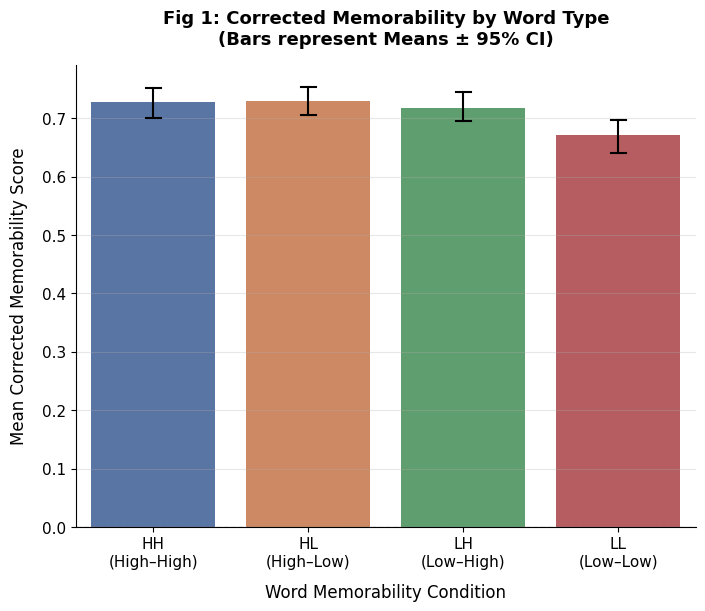

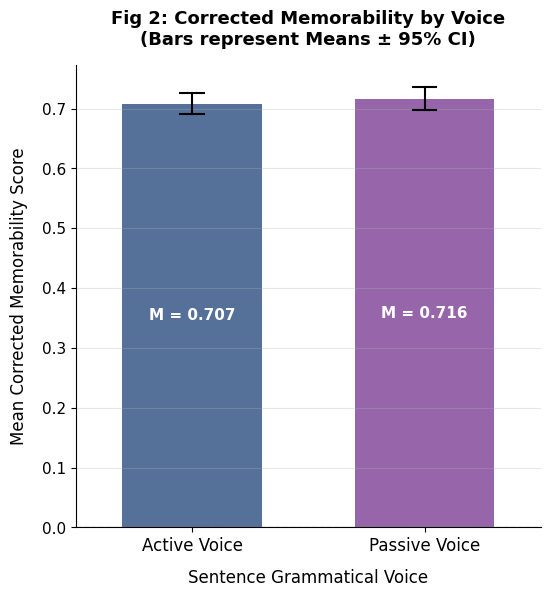

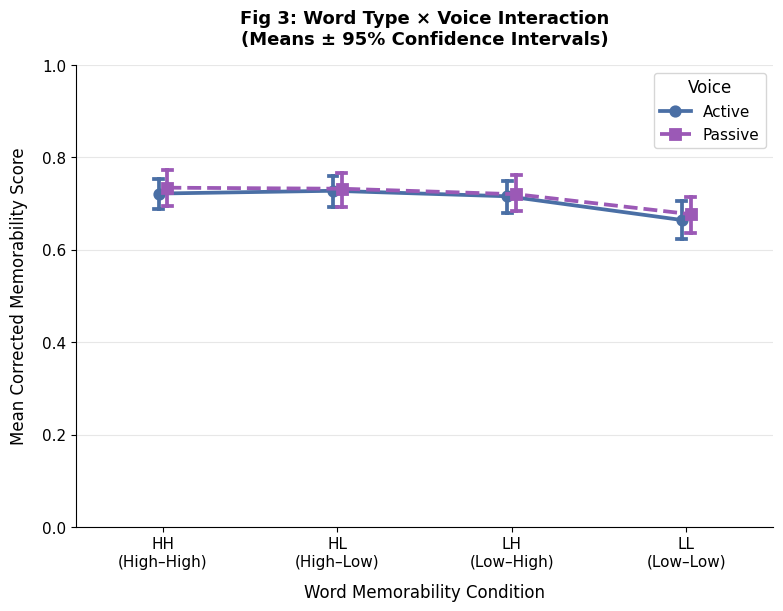

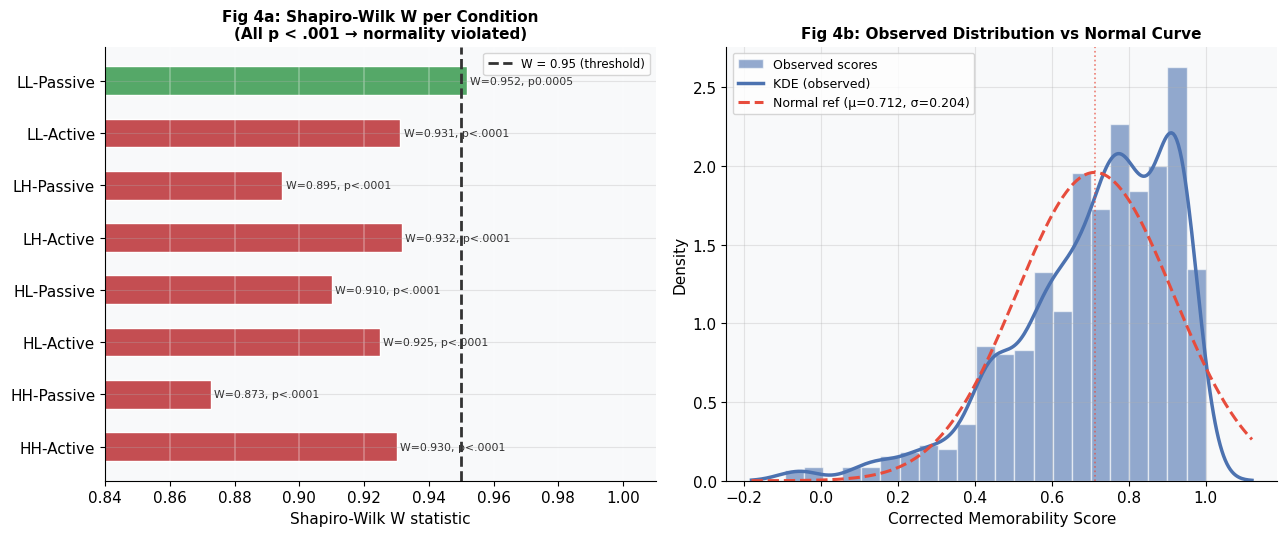

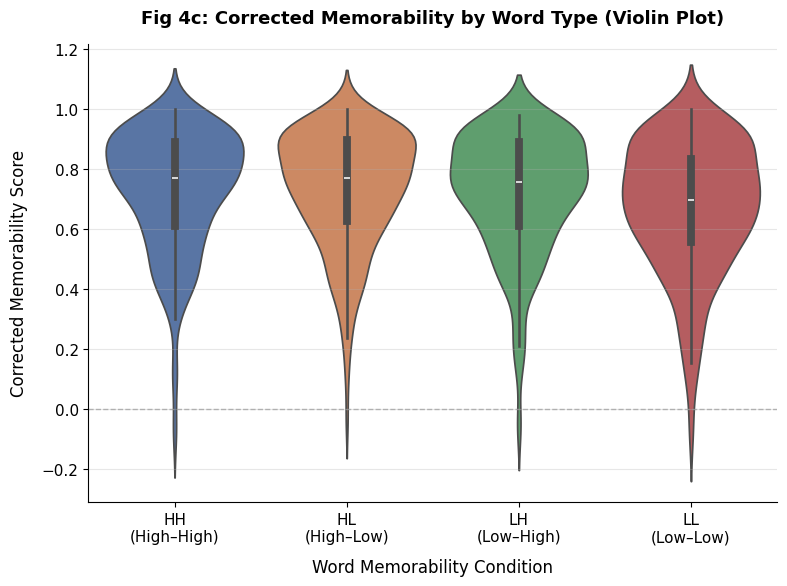

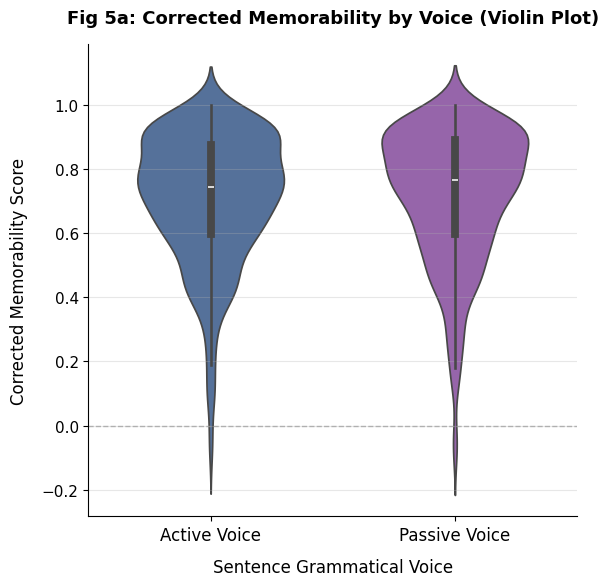

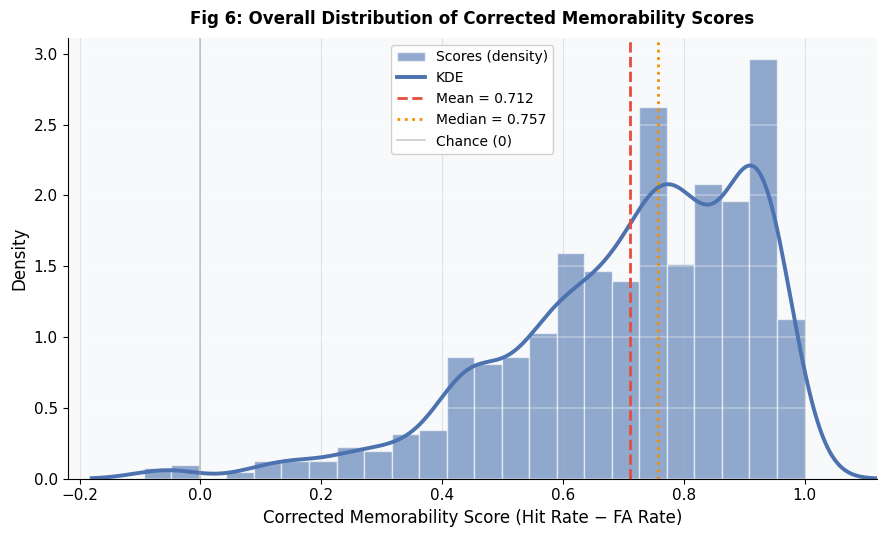

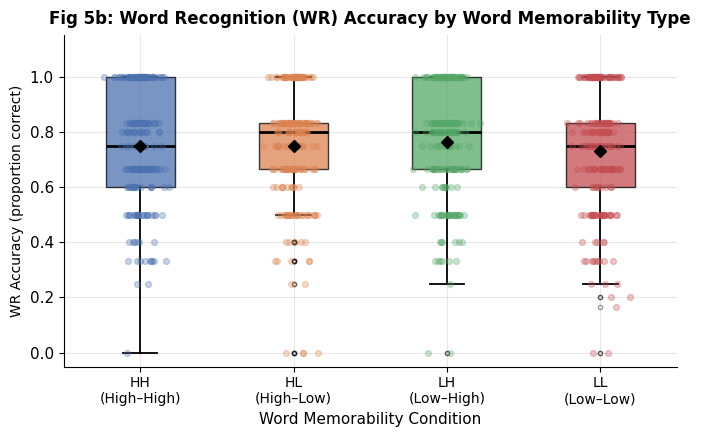

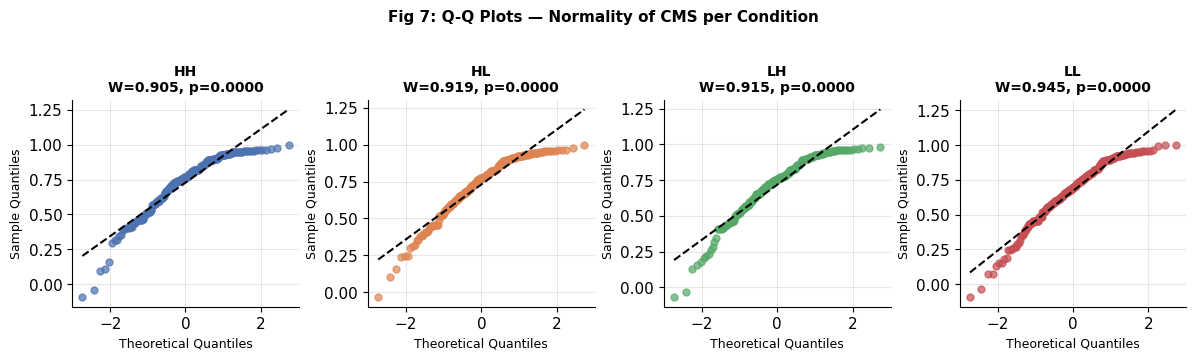

In [26]:
plot_wordtype_bar(df)
plot_voice_bar(df)
plot_interaction_clean(df)
figure4_shapiro_panel(df, sw_df)
plot_wordtype_violin(df)
plot_voice_violin(df)
figure6_distribution_hist(df)
fig5_wr_accuracy(df)
fig7_qqplots(df)
